Copyright (c) MONAI Consortium  
Licensed under the Apache License, Version 2.0 (the "License");  
you may not use this file except in compliance with the License.  
You may obtain a copy of the License at  
&nbsp;&nbsp;&nbsp;&nbsp;http://www.apache.org/licenses/LICENSE-2.0  
Unless required by applicable law or agreed to in writing, software  
distributed under the License is distributed on an "AS IS" BASIS,  
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.  
See the License for the specific language governing permissions and  
limitations under the License.

# Training and Evaluating Calibrated 3D Segmentation Models with MONAI

This tutorial trains three-dimensional hippocampus segmentation models on complete MRI volumes from the
Medical Segmentation Decathlon. It demonstrates MONAI's calibration metrics, reliability diagrams, Ignite
handler, and hard-binned L1 Average Calibration Error (ACE) auxiliary training, while contrasting hard and soft
binning. Calibration is one reliability property; these examples do not make model probabilities clinically actionable.

The losses demonstrated here were introduced by Barfoot et al. in *Average Calibration Losses for Reliable
Uncertainty in Medical Image Segmentation* (IEEE Transactions on Medical Imaging, 2026). The paper proposes
hard- and soft-binned differentiable marginal L1-ACE losses and dataset reliability histograms for studying
variation in calibration between images. Below, **the paper** refers specifically to this work:
[article](https://doi.org/10.1109/TMI.2026.3673118) and
[reference implementation](https://github.com/cai4cai/Average-Calibration-Losses).

The paper evaluates ACDC, AMOS, KiTS, and BraTS. This notebook adapts the method to the smaller Decathlon
hippocampus task as a runnable MONAI example; it is not a reproduction of the paper's experiments.


## Setup environment

In [1]:
!python3 -c "import ignite; from monai.losses import HardL1ACELoss, SoftL1ACELoss" || python3 -m pip install -q "monai-weekly[ignite]"
!python3 -c "import matplotlib, nibabel" || python3 -m pip install -q matplotlib nibabel

## Setup imports

In [2]:
%matplotlib inline

import copy
import os
import random
import re
import shutil
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from ignite.engine import Engine

import monai
from monai.apps import download_and_extract
from monai.data import CacheDataset, DataLoader
from monai.handlers import CalibrationError, from_engine
from monai.losses import DiceCELoss, HardL1ACELoss, SoftL1ACELoss
from monai.metrics import (
    CalibrationErrorMetric,
    CalibrationReduction,
    DiceMetric,
    calibration_binning,
)
from monai.networks.nets import UNet
from monai.transforms import (
    Compose,
    EnsureChannelFirstd,
    EnsureTyped,
    LoadImaged,
    NormalizeIntensityd,
    Orientationd,
    RandFlipd,
    SpatialPadd,
    Spacingd,
)
from monai.utils import set_determinism

monai.config.print_config()

MONAI version: 1.6.0rc1+67.g198bcad9


Numpy version: 2.2.6


Pytorch version: 2.8.0+cu129


MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: 198bcad9fd05b286cc525b64f814d7c1421c0eed
MONAI __file__: /workspaces/MONAI/monai/__init__.py



Optional dependencies:


...

mlflow version: 3.15.2


pynrrd version: 1.1.3


clearml version: 2.1.12



For details about installing the optional dependencies, please visit:


    https://monai.readthedocs.io/en/latest/installation.html#installing-the-recommended-dependencies



## What is calibration, and why do we care?

### Confidence that has a frequency interpretation

A segmentation network returns a probability for every voxel and class. In this tutorial, **confidence
calibration** means that those probabilities agree with observed frequencies. For class $c$, a calibrated
model satisfies

$$
P(Y_c=1\mid \hat{p}_c=p)=p.
$$

For example, among voxels assigned a probability of 0.8 for anterior hippocampus, approximately 80% should
belong to that class. If only 60% do, the model is **overconfident**; if 90% do, it is **underconfident**. We
use marginal one-versus-all calibration, applying this interpretation separately to every class rather than
only to the most probable class.

Calibration and segmentation quality answer different questions. Dice measures spatial overlap after a hard
decision, whereas calibration measures whether the probabilities supporting those decisions are meaningful.
A model can achieve high Dice while being overconfident, and a poorly discriminating model can still be
calibrated. We therefore report calibration errors together with Dice rather than treating either as a
substitute for the other.

### Why calibrated probabilities matter

Incorrect high-confidence predictions are especially problematic when probabilities inform clinical review,
quality-control thresholds, or active-learning decisions. Better calibration can make confidence maps more
useful for identifying predictions that merit inspection. It does not, by itself, establish clinical safety,
detect every distribution shift, or capture all forms of aleatoric and epistemic uncertainty.

Segmentation is unusually suitable for per-image calibration analysis because one 3D volume provides many
voxel-level probability–outcome pairs. This lets us estimate calibration for each volume and class instead of
requiring one prediction from each of many images, as in ordinary image classification.

### How to read a reliability diagram

A reliability diagram divides predicted probabilities into bins. For each occupied bin, it compares

- the mean predicted probability, shown on the horizontal axis; and
- the empirical foreground frequency, shown on the vertical axis.

Perfect calibration lies on the diagonal $y=x$. Points below the diagonal indicate overconfidence, points
above it indicate underconfidence, and the distance from the diagonal is the bin's calibration gap. A companion
count histogram is essential context: estimates from sparsely populated bins are less stable.

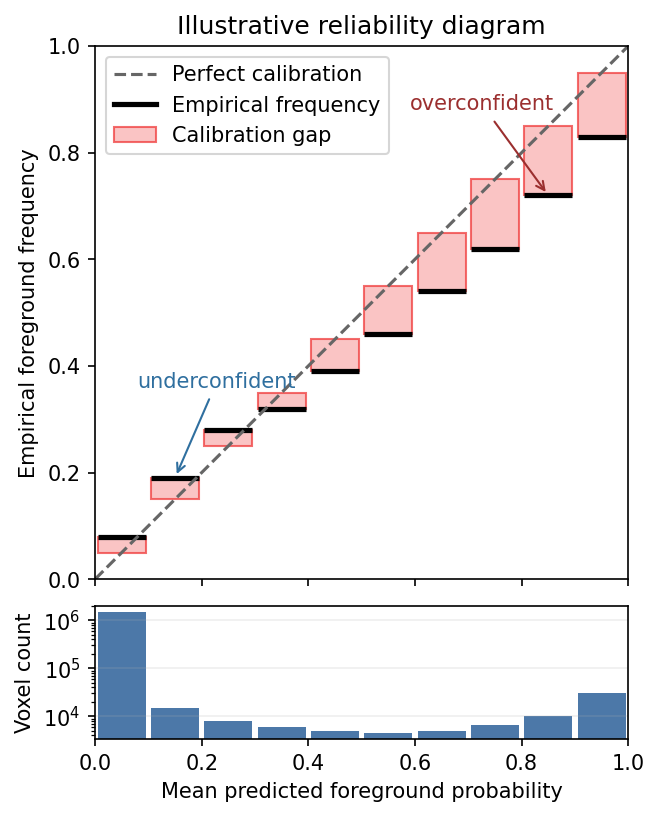

*Illustrative synthetic example. Black marks show empirical frequency, red bars show the gap to the mean
predicted probability, and the lower panel shows how much evidence supports each bin.*

Scalar calibration metrics summarize these gaps differently. Expected Calibration Error (ECE) weights each
bin by its voxel count, Average Calibration Error (ACE) weights occupied bins equally, and Maximum Calibration
Error (MCE) reports the largest occupied-bin gap. Consequently, ECE can be dominated by the very populous
near-zero and near-one bins in segmentation, while ACE gives intermediate confidence ranges equal influence.

A conventional dataset-level curve can hide differences between volumes because their errors are averaged and
may cancel. The paper therefore introduces **dataset reliability histograms**, which aggregate per-volume
reliability diagrams into a heatmap. In the figure later in this tutorial, a narrow distribution along the
diagonal indicates consistent calibration across volumes; vertical spread reveals case-to-case variability.

## Why use complete 3D volumes?

MONAI's calibration components form a separate histogram for each image and class. They flatten the spatial
dimensions but do not pool different batch items. A $64^3$ volume therefore provides 262,144 probabilities
per class, giving substantially more stable 20-bin estimates than an individual 2D slice. Volume-level
training also preserves anatomical context and makes the unit used for training, validation, and metric
aggregation consistent.

The losses use marginal one-versus-all class calibration rather than top-label confidence calibration. Training includes background to match the paper's configuration introduced above, while reported metrics
exclude it so that it cannot obscure the two small hippocampal structures.

## Download the Medical Segmentation Decathlon hippocampus task

`Task04_Hippocampus` contains 260 labeled T1-weighted MRI volumes with anterior and posterior hippocampus
labels. The compressed download is approximately 28 MB and is distributed under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/). Set `MONAI_DATA_DIRECTORY` to reuse the
download and cached transforms between runs; otherwise a temporary directory is used.

In [3]:
directory = os.environ.get("MONAI_DATA_DIRECTORY")
root_dir = Path(tempfile.mkdtemp()) if directory is None else Path(directory)
root_dir.mkdir(parents=True, exist_ok=True)
resource = "https://msd-for-monai.s3-us-west-2.amazonaws.com/Task04_Hippocampus.tar"
md5 = "9d24dba78a72977dbd1d2e110310f31b"
compressed_file = root_dir / "Task04_Hippocampus.tar"
data_dir = root_dir / "Task04_Hippocampus"

if not data_dir.exists():
    download_and_extract(resource, compressed_file, root_dir, md5, "md5")
print(f"Dataset ready: {data_dir}")

Dataset ready: /workspace/data/decathlon/Task04_Hippocampus


## Create volume-level training, validation, and test cohorts

We split before constructing datasets, so no volume contributes to more than one cohort. Thirty-two volumes
are used for training, eight for validation and hyperparameter selection, and eight are held out until the
final comparison. The remaining labeled volumes are deliberately unused to keep this worked example
accessible.

In [4]:
seed = 2026
set_determinism(seed=seed)


def natural_key(path):
    return int(re.search(r"\d+", path.name).group())


image_paths = sorted(
    (path for path in (data_dir / "imagesTr").glob("hippocampus_*.nii.gz") if not path.name.startswith("._")),
    key=natural_key,
)
split_rng = random.Random(seed)
split_rng.shuffle(image_paths)
train_paths = image_paths[:32]
val_paths = image_paths[32:40]
test_paths = image_paths[40:48]


def files(paths):
    return [{"image": str(path), "label": str(data_dir / "labelsTr" / path.name)} for path in paths]


train_files, val_files, test_files = files(train_paths), files(val_paths), files(test_paths)
print(f"Found {len(image_paths)} labeled volumes")
print(f"Using {len(train_files)} train, {len(val_files)} validation, and {len(test_files)} test volumes")

Found 260 labeled volumes
Using 32 train, 8 validation, and 8 test volumes


## Define the 3D preprocessing pipeline

The native hippocampus scans are small. After orientation and 1 mm isotropic resampling, padding every spatial
dimension to 64 gives identically shaped complete volumes without extracting slices or target-centered
patches. MRI intensities are normalized over nonzero voxels, and random flips provide lightweight training
augmentation.

In [5]:
spatial_size = (64, 64, 64)


def make_transforms(training):
    transforms = [
        LoadImaged(keys=("image", "label")),
        EnsureChannelFirstd(keys=("image", "label")),
        Orientationd(keys=("image", "label"), axcodes="RAS", labels=None),
        Spacingd(
            keys=("image", "label"),
            pixdim=(1.0, 1.0, 1.0),
            mode=("bilinear", "nearest"),
        ),
        NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
        SpatialPadd(keys=("image", "label"), spatial_size=spatial_size),
        EnsureTyped(
            keys=("image", "label"),
            dtype=(torch.float32, torch.int64),
            track_meta=False,
        ),
    ]
    if training:
        transforms.extend(
            [
                RandFlipd(keys=("image", "label"), prob=0.5, spatial_axis=0),
                RandFlipd(keys=("image", "label"), prob=0.5, spatial_axis=1),
                RandFlipd(keys=("image", "label"), prob=0.5, spatial_axis=2),
            ]
        )
    return Compose(transforms)


train_transforms = make_transforms(training=True)
eval_transforms = make_transforms(training=False)
train_ds = CacheDataset(train_files, train_transforms, cache_rate=1.0, num_workers=0, progress=False)
val_ds = CacheDataset(val_files, eval_transforms, cache_rate=1.0, num_workers=0, progress=False)
test_ds = CacheDataset(test_files, eval_transforms, cache_rate=1.0, num_workers=0, progress=False)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0)

example = val_ds[0]
print("Complete validation image:", tuple(example["image"].shape))
print("Complete validation label:", tuple(example["label"].shape))

Complete validation image: (1, 64, 64, 64)
Complete validation label: (1, 64, 64, 64)


The following view comes from a validation volume. It uses array orientation for model development and is
not intended for diagnostic interpretation.

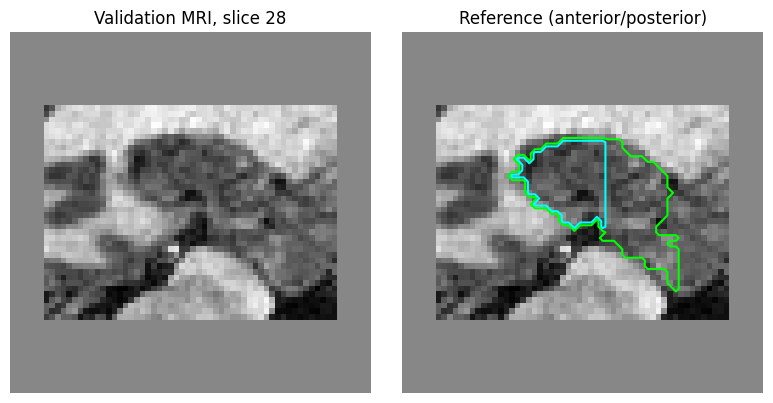

In [6]:
example_image = example["image"]
example_label = example["label"]
slice_index = int((example_label[0] > 0).sum(dim=(0, 1)).argmax())

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(example_image[0, :, :, slice_index], cmap="gray")
axes[0].set_title(f"Validation MRI, slice {slice_index}")
axes[1].imshow(example_image[0, :, :, slice_index], cmap="gray")
axes[1].contour(
    example_label[0, :, :, slice_index],
    levels=[0.5, 1.5],
    colors=["lime", "cyan"],
    linewidths=1.5,
)
axes[1].set_title("Reference (anterior/posterior)")
for axis in axes:
    axis.axis("off")
plt.tight_layout()

## Define the segmentation model and objectives

Barfoot et al. use Dice plus cross-entropy with unit coefficients as the segmentation baseline. Their
calibrated configuration gives Dice, cross-entropy, and L1-ACE equal weight:

$$\mathcal{L}_{\mathrm{paper}} =
0.33\,\mathcal{L}_{\mathrm{Dice}} +
0.33\,\mathcal{L}_{\mathrm{CE}} +
0.33\,\mathcal{L}_{\mathrm{ACE}}.$$

For this smaller Task04 cohort, a validation-only preliminary comparison found that hard L1-ACE with coefficient
0.10 gave the best calibration improvement for the least Dice reduction. The focused tutorial therefore uses

$$\mathcal{L}_{\mathrm{calibrated}} =
0.33\,\mathcal{L}_{\mathrm{Dice}} +
0.33\,\mathcal{L}_{\mathrm{CE}} +
0.10\,\mathcal{L}_{\mathrm{Hard\ L1\text{-}ACE}},$$

a ratio of approximately $1:1:0.30$. The segmentation terms are identical for baseline and calibrated training, so
the auxiliary calibration term is the only difference. The test cohort was not used to select this setting.
Both models start from identical weights and see the same shuffled, augmented volumes. Empty target classes
contribute zero before the batch-and-class mean, matching the reference loss implementation.

In [7]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")
if device.type == "cuda":
    print(torch.cuda.get_device_name(0))

# Use deterministic kernels so the saved comparison is reproducible.
torch.use_deterministic_algorithms(True)


def make_model():
    return UNet(
        spatial_dims=3,
        in_channels=1,
        out_channels=3,
        channels=(16, 32, 64, 128),
        strides=(2, 2, 2),
        num_res_units=2,
    ).to(device)


initial_state = copy.deepcopy(make_model().state_dict())
segmentation_loss = DiceCELoss(
    include_background=True,
    to_onehot_y=False,
    softmax=True,
    squared_pred=True,
    smooth_nr=0,
    smooth_dr=1.0e-5,
    lambda_dice=0.33,
    lambda_ce=0.33,
)
hard_ace = HardL1ACELoss(
    num_bins=20,
    include_background=True,
    to_onehot_y=False,
    softmax=True,
    ignore_empty_classes=True,
)
soft_ace = SoftL1ACELoss(
    num_bins=20,
    include_background=True,
    to_onehot_y=False,
    softmax=True,
    empty_weight=0.01,
    ignore_empty_classes=True,
)
calibration_weight = 0.10
max_epochs = 100
val_interval = 10

Training on: cuda:0
NVIDIA GeForce RTX 5090


## Verify that hard and soft binning are distinct

Hard L1-ACE assigns every probability to one bin. Soft L1-ACE interpolates between two neighboring bin
centers, so they are related estimators rather than numerically identical functions.

In [8]:
probe_model = make_model()
probe_model.load_state_dict(initial_state)
with torch.no_grad():
    probe_logits = probe_model(example_image[None].to(device))
    probe_target = F.one_hot(example_label[None, 0].long(), num_classes=3).movedim(-1, 1).float().to(device)
    hard_value = hard_ace(probe_logits, probe_target).item()
    soft_value = soft_ace(probe_logits, probe_target).item()
print(f"Same 3D logits: hard L1-ACE={hard_value:.6f}, soft L1-ACE={soft_value:.6f}")
print(f"Absolute difference: {abs(hard_value - soft_value):.6f}")
del probe_model, probe_logits, probe_target

Same 3D logits: hard L1-ACE=0.479469, soft L1-ACE=0.478980
Absolute difference: 0.000489


## Train baseline and calibrated models

Each run selects its checkpoint by validation Dice. Explicit one-hot targets are shared by the segmentation and
calibration objectives, enabling deterministic CUDA training. The test cohort remains untouched until both
checkpoints have been fixed.

In [9]:
def evaluate(model, loader, store_predictions=False):
    dice_metric = DiceMetric(include_background=False, reduction="mean")
    calibration_metrics = {
        "ECE": CalibrationErrorMetric(
            num_bins=20,
            include_background=False,
            calibration_reduction=CalibrationReduction.EXPECTED,
        ),
        "ACE": CalibrationErrorMetric(
            num_bins=20,
            include_background=False,
            calibration_reduction=CalibrationReduction.AVERAGE,
        ),
        "MCE": CalibrationErrorMetric(
            num_bins=20,
            include_background=False,
            calibration_reduction=CalibrationReduction.MAXIMUM,
        ),
    }
    probabilities, targets = [], []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            image = batch["image"].to(device)
            label = batch["label"].to(device)
            probability = torch.softmax(model(image), dim=1)
            target = F.one_hot(label[:, 0], num_classes=3).movedim(-1, 1).float()
            prediction = F.one_hot(probability.argmax(dim=1), num_classes=3).movedim(-1, 1).float()
            dice_metric(y_pred=prediction, y=target)
            for metric in calibration_metrics.values():
                metric(y_pred=probability, y=target)
            if store_predictions:
                probabilities.append(probability.cpu())
                targets.append(target.cpu())
    scores = {"Dice": dice_metric.aggregate().item()}
    scores.update({name: metric.aggregate().item() for name, metric in calibration_metrics.items()})
    if store_predictions:
        return scores, torch.cat(probabilities), torch.cat(targets)
    return scores


def train_variant(calibration_loss=None, calibration_weight=0.0):
    set_determinism(seed=seed)
    train_transforms.set_random_state(seed=seed)
    generator = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(
        train_ds,
        batch_size=2,
        shuffle=True,
        generator=generator,
        num_workers=0,
        pin_memory=True,
    )
    model = make_model()
    model.load_state_dict(initial_state)
    optimizer = torch.optim.AdamW(model.parameters(), lr=2.0e-3, weight_decay=1.0e-5)
    scaler = torch.amp.GradScaler("cuda", enabled=device.type == "cuda")
    best_state = None
    best_epoch = 0
    best_val_dice = float("-inf")
    for epoch in range(1, max_epochs + 1):
        model.train()
        running_loss = 0.0
        for batch in train_loader:
            image = batch["image"].to(device, non_blocking=True)
            label = batch["label"].to(device, non_blocking=True)
            target = F.one_hot(label[:, 0], num_classes=3).movedim(-1, 1).float()
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=device.type == "cuda"):
                logits = model(image)
                loss = segmentation_loss(logits, target)
                if calibration_loss is not None:
                    loss = loss + calibration_weight * calibration_loss(logits, target)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()
        mean_training_loss = running_loss / len(train_loader)
        if epoch % val_interval == 0 or epoch == max_epochs:
            val_scores = evaluate(model, val_loader)
            if epoch % (2 * val_interval) == 0 or epoch == max_epochs:
                print(
                    f"epoch {epoch:03d}: loss={mean_training_loss:.4f}, "
                    f"validation Dice={val_scores['Dice']:.4f}, "
                    f"validation ACE={val_scores['ACE']:.4f}"
                )
            if val_scores["Dice"] > best_val_dice:
                best_val_dice = val_scores["Dice"]
                best_epoch = epoch
                best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
    model.load_state_dict(best_state)
    val_scores = evaluate(model, val_loader)
    print(f"selected epoch {best_epoch}: Dice={val_scores['Dice']:.4f}, " f"ACE={val_scores['ACE']:.4f}")
    return best_state, val_scores

In [10]:
calibrated_name = "hard L1-ACE"
configurations = {
    "segmentation only": None,
    calibrated_name: hard_ace,
}

states, validation_results = {}, {}
for name, calibration_loss in configurations.items():
    print(f"\nTraining: {name}")
    states[name], validation_results[name] = train_variant(
        calibration_loss,
        calibration_weight if calibration_loss is not None else 0.0,
    )
model_names = list(configurations)


Training: segmentation only


epoch 020: loss=0.0509, validation Dice=0.7388, validation ACE=0.1009


epoch 040: loss=0.0323, validation Dice=0.8088, validation ACE=0.1050


epoch 060: loss=0.0290, validation Dice=0.8055, validation ACE=0.1117


epoch 080: loss=0.0250, validation Dice=0.7838, validation ACE=0.1168


...

epoch 040: loss=0.0462, validation Dice=0.8017, validation ACE=0.0850


epoch 060: loss=0.0379, validation Dice=0.7918, validation ACE=0.0992


epoch 080: loss=0.0382, validation Dice=0.8154, validation ACE=0.1056


epoch 100: loss=0.0326, validation Dice=0.8119, validation ACE=0.0963


selected epoch 90: Dice=0.8167, ACE=0.0945


## Compare validation performance

The selected coefficient is fixed before test evaluation. This table verifies the two saved checkpoints on the
validation cohort; Dice is higher when better, while ECE, ACE, and MCE are lower when better.

In [11]:
print(f"{'configuration':<20} {'Dice':>10} {'ECE':>10} {'ACE':>10} {'MCE':>10}")
for name, scores in validation_results.items():
    print(f"{name:<20} {scores['Dice']:10.6f} {scores['ECE']:10.6f} " f"{scores['ACE']:10.6f} {scores['MCE']:10.6f}")

configuration              Dice        ECE        ACE        MCE
segmentation only      0.818400   0.000985   0.106519   0.259649
hard L1-ACE            0.816666   0.000965   0.094508   0.245661


## Evaluate the untouched test cohort

The two fixed checkpoints are now evaluated on the held-out test volumes. This is the first use of the test cohort.
Dice is higher when better; ECE, ACE, and MCE are lower when better.

In [12]:
test_results, stored_predictions = {}, {}
stored_targets = None
for name in model_names:
    model = make_model()
    model.load_state_dict(states[name])
    scores, probabilities, targets = evaluate(model, test_loader, store_predictions=True)
    test_results[name] = scores
    stored_predictions[name] = probabilities
    stored_targets = targets
    del model

print(f"{'configuration':<20} {'Dice':>10} {'ECE':>10} {'ACE':>10} {'MCE':>10}")
for name, scores in test_results.items():
    print(f"{name:<20} {scores['Dice']:10.6f} {scores['ECE']:10.6f} " f"{scores['ACE']:10.6f} {scores['MCE']:10.6f}")

baseline = test_results["segmentation only"]
calibrated = test_results[calibrated_name]
dice_change = calibrated["Dice"] - baseline["Dice"]
ace_improvement = baseline["ACE"] - calibrated["ACE"]
print("\nChange from segmentation only (positive ACE change is an improvement):")
print(f"{calibrated_name:<20} Dice {dice_change:+.6f}, ACE {ace_improvement:+.6f}")

configuration              Dice        ECE        ACE        MCE
segmentation only      0.799317   0.001060   0.117391   0.295517
hard L1-ACE            0.828645   0.001032   0.090355   0.208534

Change from segmentation only (positive ACE change is an improvement):
hard L1-ACE          Dice +0.029327, ACE +0.027036


In the saved run, the validation checkpoints differ by only 0.0017 Dice while hard L1-ACE lowers ACE from
0.1065 to 0.0945. On the untouched test cohort, it raises Dice from 0.7993 to 0.8286 and lowers ACE from 0.1174
to 0.0904, a 23% relative reduction. This small single-split result demonstrates the possible trade-off; it is
not a guarantee that every dataset or training run will improve both measures.

The fixed zero-to-one probability maps below show the same held-out volume for both models.

## Inspect held-out probability maps

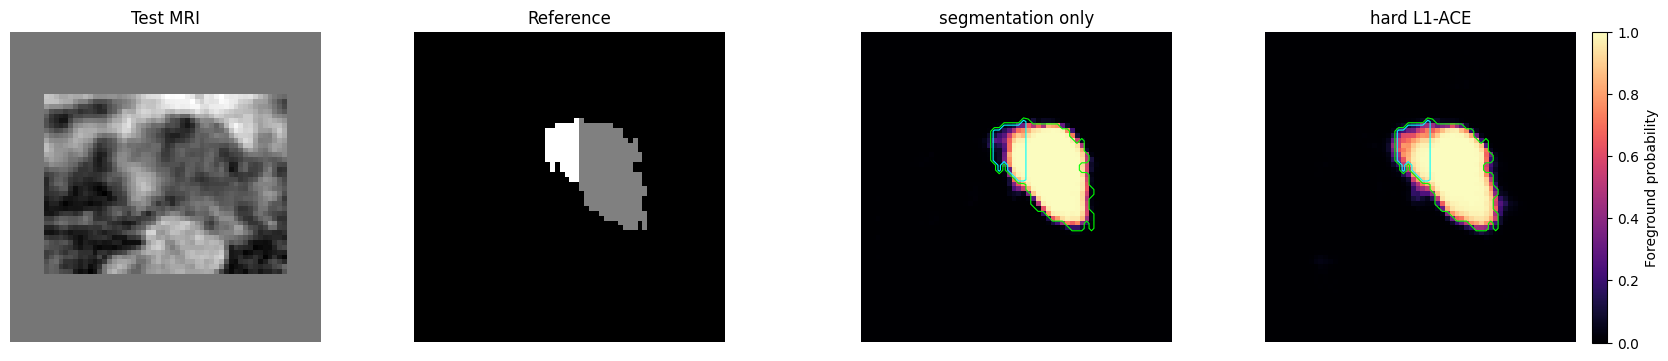

In [13]:
test_example = test_ds[0]
test_image = test_example["image"]
test_label = test_example["label"]
test_slice_index = int((test_label[0] > 0).sum(dim=(0, 1)).argmax())

fig, axes = plt.subplots(1, 2 + len(model_names), figsize=(17, 3.5), layout="constrained")
axes[0].imshow(test_image[0, :, :, test_slice_index], cmap="gray")
axes[0].set_title("Test MRI")
axes[1].imshow(test_label[0, :, :, test_slice_index], cmap="gray", vmin=0, vmax=2)
axes[1].set_title("Reference")
probability_image = None
for axis, name in zip(axes[2:], model_names):
    foreground_probability = stored_predictions[name][0, 1:].sum(dim=0)
    probability_image = axis.imshow(
        foreground_probability[:, :, test_slice_index],
        cmap="magma",
        vmin=0,
        vmax=1,
    )
    axis.contour(
        test_label[0, :, :, test_slice_index],
        levels=[0.5, 1.5],
        colors=["lime", "cyan"],
        linewidths=0.8,
    )
    axis.set_title(name)
for axis in axes:
    axis.axis("off")
fig.colorbar(
    probability_image,
    ax=axes[2:],
    label="Foreground probability",
    fraction=0.02,
    pad=0.02,
)
plt.show()

## Inspect publication-style dataset reliability histograms

A conventional pooled reliability curve hides variation between volumes. The paper therefore introduces a
**dataset reliability histogram**. For every held-out volume and foreground class, we first use MONAI's
`calibration_binning` to calculate the empirical foreground frequency in each predicted-probability bin. The
top row then shows the distribution of those per-volume frequencies: each heatmap column is normalized
independently, and perfect calibration lies on the dashed diagonal. A narrow distribution along that diagonal
is desirable; vertical spread exposes variation between volumes that an average curve would conceal.

The lower row reports the total number of foreground-class voxel probabilities in each prediction bin, using a
log scale when needed. To keep the comparison compact, the two hippocampal foreground classes contribute to
the same histogram, while background remains excluded. As with the paper's figure, this is a descriptive
visualization; the tabulated metrics retain their stated per-volume, per-class reductions.

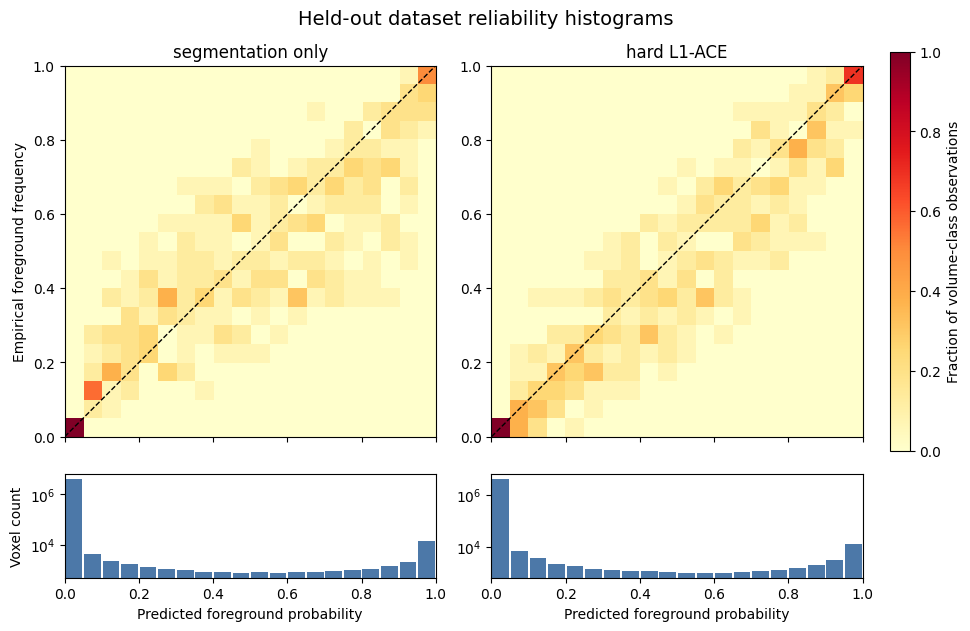

In [14]:
num_bins = 20
bin_edges = torch.linspace(0.0, 1.0 + torch.finfo(torch.float32).eps, num_bins + 1)
bin_width = 1.0 / num_bins
bin_positions = torch.linspace(bin_width / 2, 1.0 - bin_width / 2, num_bins)

fig, axes = plt.subplots(
    2,
    len(model_names),
    figsize=(4.8 * len(model_names), 6.2),
    sharex=True,
    gridspec_kw={"height_ratios": [4, 1]},
    layout="constrained",
)
if len(model_names) == 1:
    axes = axes[:, None]

heatmap_images = []
for column, name in enumerate(model_names):
    probabilities = stored_predictions[name][:, 1:]
    targets = stored_targets[:, 1:]
    _, empirical_frequency, counts = calibration_binning(probabilities, targets, num_bins=num_bins)

    # Match the paper's dataset histogram: bin each per-volume empirical frequency along the y-axis.
    empirical_frequency = empirical_frequency.reshape(-1, num_bins).cpu()
    heatmap = torch.zeros(num_bins, num_bins, dtype=torch.float32)
    for probability_bin in range(num_bins):
        frequency = empirical_frequency[:, probability_bin]
        frequency = frequency[torch.isfinite(frequency)]
        frequency_bin = torch.bucketize(frequency.contiguous(), bin_edges[1:], right=False)
        frequency_bin = frequency_bin.clamp(max=num_bins - 1)
        heatmap[:, probability_bin].scatter_add_(0, frequency_bin, torch.ones_like(frequency_bin, dtype=heatmap.dtype))

    column_total = heatmap.sum(dim=0, keepdim=True)
    heatmap = torch.where(column_total > 0, heatmap / column_total, torch.zeros_like(heatmap))
    reliability_axis = axes[0, column]
    heatmap_images.append(
        reliability_axis.imshow(
            heatmap.numpy(),
            origin="lower",
            extent=(0, 1, 0, 1),
            aspect="equal",
            cmap="YlOrRd",
            vmin=0,
            vmax=1,
            interpolation="nearest",
        )
    )
    reliability_axis.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1)
    reliability_axis.set_title(name)
    reliability_axis.set_xlim(0, 1)
    reliability_axis.set_ylim(0, 1)
    if column == 0:
        reliability_axis.set_ylabel("Empirical foreground frequency")

    count_axis = axes[1, column]
    aggregate_counts = counts.sum(dim=(0, 1)).cpu()
    count_axis.bar(bin_positions, aggregate_counts, width=0.9 * bin_width, color="#4c78a8")
    nonzero_counts = aggregate_counts[aggregate_counts > 0]
    if len(nonzero_counts) and nonzero_counts.max() / nonzero_counts.min() > 100:
        count_axis.set_yscale("log")
    count_axis.set_xlim(0, 1)
    count_axis.set_xlabel("Predicted foreground probability")
    if column == 0:
        count_axis.set_ylabel("Voxel count")

fig.colorbar(
    heatmap_images[-1],
    ax=list(axes[0]),
    label="Fraction of volume-class observations",
    fraction=0.025,
    pad=0.02,
)
fig.suptitle("Held-out dataset reliability histograms", fontsize=14)
plt.show()

## Optional Ignite handler example

`CalibrationError` wraps the metric for an Ignite evaluator. The engine below evaluates complete 3D volumes
and writes the aggregate foreground ECE to `engine.state.metrics`.

In [15]:
handler_model = make_model()
handler_model.load_state_dict(states["segmentation only"])


def evaluation_step(engine, batch):
    del engine
    image = batch["image"].to(device)
    label = batch["label"].to(device)
    handler_model.eval()
    with torch.no_grad():
        probability = torch.softmax(handler_model(image), dim=1)
    target = F.one_hot(label[:, 0], num_classes=3).movedim(-1, 1).float()
    return {"pred": probability, "label": target}


evaluator = Engine(evaluation_step)
CalibrationError(
    num_bins=20,
    include_background=False,
    calibration_reduction="expected",
    output_transform=from_engine(["pred", "label"]),
).attach(evaluator, "foreground_ece")
evaluator.run(test_loader)
print(evaluator.state.metrics)

{'foreground_ece': 0.0010597537038847804}


## Practical guidance and limitations

- Split medical data by patient or volume before constructing datasets.
- Use genuinely 3D inputs when calibration bins should represent volume-scale voxel distributions.
- Select the bin count and auxiliary coefficient on validation data, never on the test cohort.
- Report segmentation quality beside calibration because lower calibration error can accompany lower Dice.
- Decide whether background is scientifically meaningful; it can dominate small foreground structures.
- Empty target classes contribute zero in these losses, matching the paper's reference implementation.
- Hard assignments have discrete bin boundaries. Soft assignments interpolate between neighboring centers.
- Finite-bin estimates depend on bin count, spatial support, and aggregation. State whether results are
  per-volume or pooled.
- This tutorial uses a modest cohort and one seed to remain runnable. A study should use all available
  training data, multiple seeds, and confidence intervals.
- Calibration does not by itself establish uncertainty quality, robustness, or clinical safety.

## Clean up

A user-specified data directory is preserved for reuse. Only a temporary directory created by this notebook is
removed.

In [16]:
torch.use_deterministic_algorithms(False)
set_determinism(seed=None)
if directory is None:
    shutil.rmtree(root_dir)
    print("Removed temporary dataset directory")

## References

1. T. Barfoot, L. C. Garcia-Peraza-Herrera, S. Akcay, B. Glocker, and T. Vercauteren,
   “Average Calibration Losses for Reliable Uncertainty in Medical Image Segmentation,”
   *IEEE Transactions on Medical Imaging*, vol. 45, no. 7, pp. 3412–3423, 2026.
   [doi:10.1109/TMI.2026.3673118](https://doi.org/10.1109/TMI.2026.3673118).
2. T. Barfoot, L. C. Garcia Peraza Herrera, B. Glocker, and T. Vercauteren,
   “Average Calibration Error: A Differentiable Loss for Improved Reliability in Image Segmentation,”
   MICCAI 2024. [Paper](https://papers.miccai.org/miccai-2024/091-Paper3075.html).
3. M. Antonelli et al., “The Medical Segmentation Decathlon,” *Nature Communications*, vol. 13,
   article 4128, 2022. [doi:10.1038/s41467-022-30695-9](https://doi.org/10.1038/s41467-022-30695-9).
4. C. Guo, G. Pleiss, Y. Sun, and K. Q. Weinberger, “On Calibration of Modern Neural Networks,”
   ICML 2017.